# How the 2D-1D deconvolution works, step by step

NGC 3110, CO(2-1), ALMA project 2017.1.00255.S. This notebook rebuilds the
**compact-configuration** deconvolved cube from scratch, **using only the compact
data**, and explains every step with a plot. At the end the result is checked
against the **extended** configuration, which was observed separately and never
enters the compact deconvolution.

The steps:

| # | step | what it does |
|---|---|---|
| 1 | inputs | the dirty cube and the dirty beam (PSF) from `tclean` |
| 2 | PSF at 2x the field | why the PSF must be imaged twice as large as the image |
| 3 | rebinning | 0.02" to 0.04" pixels, to make each iteration 4x cheaper |
| 4 | measurement operator | how a trial sky becomes a predicted dirty cube |
| 5 | sparsity dictionary | 2D starlet (space) x 1D CDF 9/7 wavelet (velocity) |
| 6 | noise model and thresholds | the real, correlated noise sets how much each wavelet band is penalized |
| 7 | the solver | Condat-Vu primal-dual iteration, 20,000 iterations on the GPU |
| 8 | why so many iterations | the weakly measured scales converge last |
| 9 | restoration and units | convolving the model with a clean beam; Jy/beam vs Jy/arcsec$^2$ |
| 10 | validation | compare with the independent extended data |
| 11 | the extended cube | what is different there (support mask) |

Code: `simple/gpu_pd.py` (GPU implementation of everything below).

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from astropy.io import fits
import torch

sys.path.insert(0, os.path.abspath("../simple"))
import gpu_pd as G
from restore import convolve_with_beam, gaussian_beam

plt.rcParams.update({"font.family": "serif", "font.size": 12, "axes.titlesize": 12,
                     "xtick.direction": "in", "ytick.direction": "in", "xtick.top": True, "ytick.right": True})
print("device:", G.DEV, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

DATA = "../data/ngc3110"
CELL = 0.02                                   # arcsec per pixel of the tclean cubes
BEAM_C = (1.418, 0.976, 83.5)                 # compact clean beam: bmaj, bmin ["], PA [deg]
BEAM_E = (0.220, 0.172, -74.7)                # extended clean beam
vel = 5073.9 + 25.0 * (np.arange(32) - 15.5)  # channel velocities, km/s (LSRK, radio)
LINE = [i for i, v in enumerate(vel) if 4750 <= v <= 5280]
NOISE = [i for i in range(32) if i not in LINE]
print(f"line channels {LINE[0]}-{LINE[-1]}, line-free channels {NOISE}")

def read(path):
    return np.nan_to_num(fits.getdata(path).astype(np.float64)).squeeze()

def mom0(cube):
    return cube[LINE].sum(0) * 25.0          # x 25 km/s channel width

C10 = np.s_[150:650, 150:650]                 # central 10" of the 800 x 800 grid
EXT10 = [5, -5, -5, 5]                        # RA increases to the left

def draw_beam(ax, b, x0=3.6, y0=-3.8, col="w"):
    ax.add_patch(Ellipse((x0, y0), width=b[0], height=b[1], angle=90 - b[2], fc="none", ec=col, lw=1.5))

def axlabels(ax):
    ax.set_xlabel(r'$\Delta$RA ["]'); ax.set_ylabel(r'$\Delta$Dec ["]')

device: cuda NVIDIA A100-SXM4-40GB
line channels 3-23, line-free channels [0, 1, 2, 24, 25, 26, 27, 28, 29, 30, 31]


## 1. The inputs: dirty cube and dirty beam

An interferometer does not take a picture. Each antenna pair measures one
Fourier component of the sky (a **visibility**), and the array only covers
part of the Fourier plane. `tclean` grids those visibilities and Fourier
transforms them into two cubes:

* the **dirty beam** (point spread function, PSF) $B$: the image the array
  would make of a single point source. It has a central peak plus
  **sidelobes**, the ripples caused by the Fourier components the array did
  not measure;
* the **dirty cube** $d$: the true sky $x$ seen through that beam, plus noise,

$$ d \;=\; B \ast x \;+\; n \qquad\text{(one 2D convolution per velocity channel).}$$

Deconvolution means going back from $d$ to $x$. The two cubes here are 32
channels of 25 km/s, 0.02" pixels, natural weighting. The dirty cube is 16"
across (800 px); the PSF is 32" across (1600 px), for reasons explained in
step 2. The dirty cube is in **Jy/beam**: each pixel is flux per dirty-beam
area.

dirty cube (32, 800, 800)  PSF cube (32, 1600, 1600)


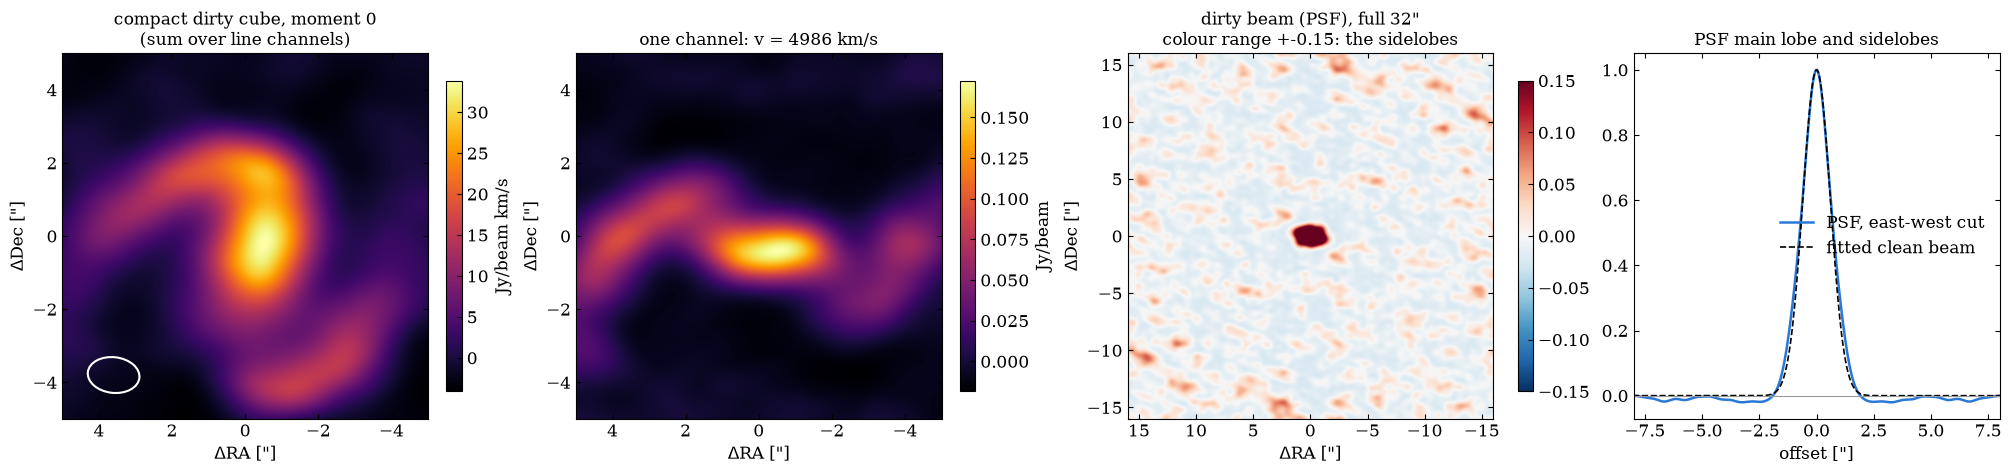

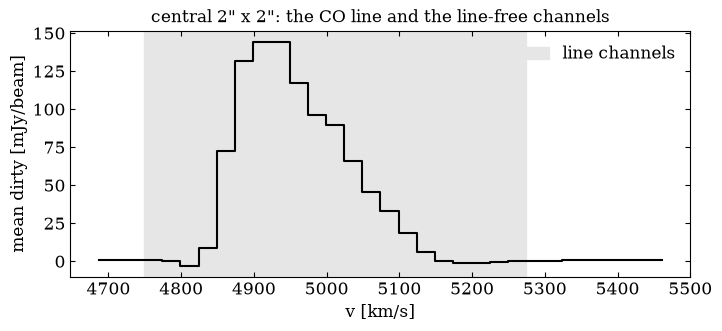

In [3]:
dirty_full = read(f"{DATA}/compact/cube/dirty_cube.fits")
psf_full = read(f"{DATA}/compact/cube/dirty_beam_cube.fits")
print("dirty cube", dirty_full.shape, " PSF cube", psf_full.shape)

fig, ax = plt.subplots(1, 4, figsize=(20, 4.6), constrained_layout=True)
im = ax[0].imshow(mom0(dirty_full)[C10], origin="lower", extent=EXT10, cmap="inferno")
ax[0].set_title("compact dirty cube, moment 0\n(sum over line channels)"); draw_beam(ax[0], BEAM_C); axlabels(ax[0])
plt.colorbar(im, ax=ax[0], label="Jy/beam km/s", shrink=0.85)
im = ax[1].imshow(dirty_full[12][C10], origin="lower", extent=EXT10, cmap="inferno")
ax[1].set_title(f"one channel: v = {vel[12]:.0f} km/s"); axlabels(ax[1]); plt.colorbar(im, ax=ax[1], label="Jy/beam", shrink=0.85)
p = psf_full[16]; cy, cx = np.unravel_index(p.argmax(), p.shape)
im = ax[2].imshow(p, origin="lower", extent=[16, -16, -16, 16], cmap="RdBu_r", vmin=-0.15, vmax=0.15)
ax[2].set_title("dirty beam (PSF), full 32\"\ncolour range +-0.15: the sidelobes"); axlabels(ax[2]); plt.colorbar(im, ax=ax[2], shrink=0.85)
off = (np.arange(p.shape[1]) - cx) * CELL
ax[3].plot(off, p[cy], color="#2a78d6", lw=1.8, label="PSF, east-west cut")
ax[3].plot(off, gaussian_beam(p.shape, CELL, *BEAM_C, center=(cy, cx))[cy], "k--", lw=1.2, label="fitted clean beam")
ax[3].axhline(0, color="0.6", lw=0.8); ax[3].set_xlim(-8, 8); ax[3].set_xlabel('offset ["]'); ax[3].legend(frameon=False)
ax[3].set_title("PSF main lobe and sidelobes")
plt.show()

spec = dirty_full[:, 350:450, 350:450].mean((1, 2)) * 1e3
plt.figure(figsize=(8, 3.2)); plt.step(vel, spec, where="mid", color="k")
plt.axvspan(vel[LINE[0]] - 12.5, vel[LINE[-1]] + 12.5, color="0.9", zorder=0, label="line channels")
plt.xlabel("v [km/s]"); plt.ylabel("mean dirty [mJy/beam]"); plt.title('central 2" x 2": the CO line and the line-free channels'); plt.legend(frameon=False); plt.show()

## 2. Why the PSF is imaged at twice the field

Written out pixel by pixel, the convolution is

$$ d(\mathbf p) \;=\; \sum_{\mathbf q\,\in\,\text{field}} B(\mathbf p-\mathbf q)\; x(\mathbf q). $$

Both $\mathbf p$ and $\mathbf q$ lie inside the 16" field, so the offset
$\mathbf p-\mathbf q$ ranges from $-16"$ to $+16"$: the model needs the PSF out
to $\pm16"$ from its peak, a 32" image. A PSF only as large as the field
stops at $\pm8"$, and two things go wrong:

1. **Missing sidelobes.** Emission near one edge of the field should send
   sidelobes to the opposite edge, through PSF values beyond $\pm8"$. With a
   field-sized PSF those values do not exist, so the model predicts nothing
   there, and the solver has to invent structure to explain what the data
   actually show.
2. **A problem that is no longer well posed.** The true operator
   $N = A^{\mathsf H}WA$ is positive semi-definite: $x^{\mathsf T}Nx\ge0$ for every
   $x$, since it is the weighted power of $x$'s visibilities. A truncated PSF
   breaks this, giving $N$ **negative eigenvalues**. Along those directions
   the data-fit term decreases without limit, so it has no minimum there.

Both effects are tested below on one channel. The smallest eigenvalue comes
from power iteration on $\lambda_{\max}I - N$; the missing sidelobe is the
predicted response, at the opposite corner, to a point source near one
corner.

PSF 2x the field (32")   eigenvalues of N: max   5097.3, min   +0.00   response at the opposite corner: -0.0038
PSF = the field (16")    eigenvalues of N: max   4957.1, min   -1.26   response at the opposite corner: -0.0000


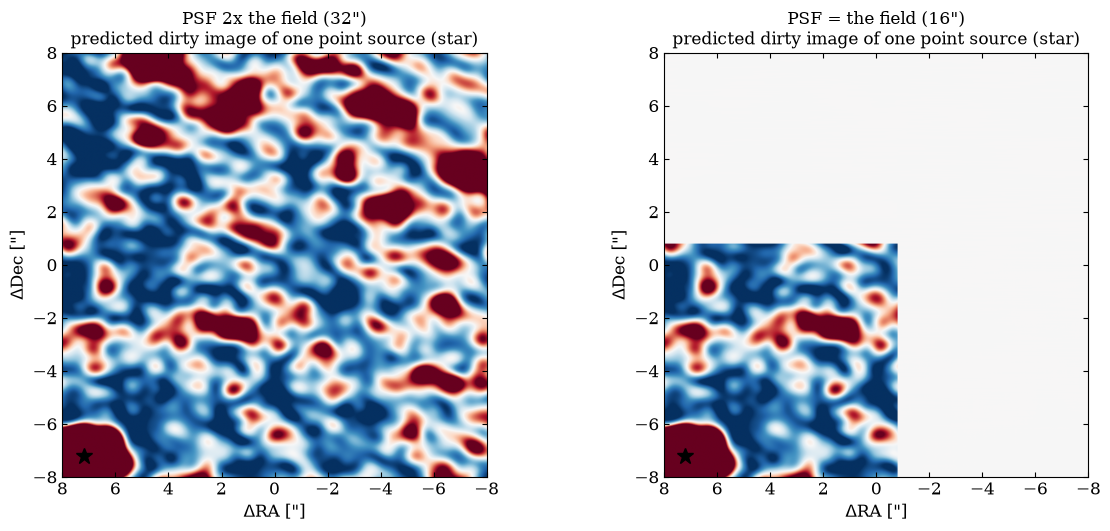

In [5]:
def extreme_eigs(op, n=300):
    # largest and smallest eigenvalue of N on the field, by power iteration
    lmax = G.field_lipschitz(op, n=60, margin=1.0)
    v = torch.randn_like(op.d)
    for _ in range(n):
        w = lmax * v - op.apply(v); mu = float(w.norm() / v.norm()); v = w / w.norm()
    return lmax, lmax - mu

ch = 16; p = psf_full[ch:ch + 1]; cy, cx = np.unravel_index(p[0].argmax(), p[0].shape)
cases = {"PSF 2x the field (32\")": p, "PSF = the field (16\")": p[:, cy - 400:cy + 400, cx - 400:cx + 400]}
resp = {}
for name, ps in cases.items():
    o = G.Op(ps, dirty_full[ch:ch + 1])
    lmax, lmin = extreme_eigs(o)
    x = torch.zeros_like(o.d); x[0, 40, 40] = 1.0                      # point source near one corner
    resp[name] = o.apply(x).cpu().numpy()[0]
    print(f"{name:<24} eigenvalues of N: max {lmax:8.1f}, min {lmin:+7.2f}   "
          f"response at the opposite corner: {resp[name][-40, -40]:+.4f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
for a, (name, r) in zip(ax, resp.items()):
    a.imshow(r, origin="lower", cmap="RdBu_r", vmin=-0.02, vmax=0.02, extent=[8, -8, -8, 8])
    a.plot((400 - 40) * CELL, (40 - 400) * CELL, "k*", ms=12)
    a.set_title(f"{name}\npredicted dirty image of one point source (star)"); axlabels(a)
plt.show()
del resp

## 3. Rebinning to 0.04" pixels

The compact beam is 1.42" x 0.98", which is 71 x 49 pixels at 0.02": far
more finely sampled than needed. Averaging 2 x 2 blocks gives 0.04" pixels,
still about 30 pixels per beam, and makes every iteration about 4x cheaper.

For the relation $d = B\ast x$ to still hold on the coarse grid (to about 2%,
checked below), the three quantities are binned differently:

* the dirty cube (Jy/beam, a *density*) by the **block mean**;
* the sky model (Jy/pixel, a *flux*) by the **block sum**;
* the PSF: smoothed twice with a 2 x 2 box, then sampled every second pixel
  from its peak.

At the end, the model is split back onto the 0.02" grid, each coarse pixel
into 4 equal parts, which conserves flux.

In [7]:
dirty, psf = G.rebin(dirty_full, psf_full, 2)
print("binned dirty", dirty.shape, " binned PSF", psf.shape)

# check: predicting the dirty cube on the fine grid, then binning, equals binning, then predicting
ref = np.load(f"{DATA}/extended/pd/model.npy").astype(np.float64)[:8]          # any realistic sky
op_fine = G.Op(psf_full[:8], dirty_full[:8]); op_bin = G.Op(psf[:8], dirty[:8])
fine = op_fine.apply(G.to_t(ref)).cpu().numpy()
fine_binned = fine.reshape(8, 400, 2, 400, 2).mean((2, 4))
binned = op_bin.apply(G.to_t(ref.reshape(8, 400, 2, 400, 2).sum((2, 4)))).cpu().numpy()
print(f"rebinning check: |difference| / peak = {np.abs(binned - fine_binned).max() / fine_binned.max():.1e}")
del op_fine, op_bin, fine, fine_binned, binned, ref

binned dirty (32, 400, 400)  binned PSF (32, 800, 800)
rebinning check: |difference| / peak = 1.9e-02


## 4. The measurement operator and the data term

For a trial sky $x$ in Jy/pixel, the predicted dirty cube is $Nx = B\ast x$.
It is computed with FFTs, per channel, on a zero-padded grid so the
convolution does not wrap around. How well $x$ explains the data is measured
by

$$ f(x) \;=\; \tfrac12\, x^{\mathsf T} N x \;-\; d^{\mathsf T} x ,
\qquad \nabla f(x) \;=\; N x - d \;=\; -\,\text{residual}. $$

For a single pointing with natural weighting, this is exactly the
visibility $\chi^2$ rewritten in the image domain:
$\tfrac12\|V - \mathcal A x\|^2_{w} = f(x) + \text{const}$. So fitting $f$ is
fitting the visibilities, without touching them again.

Two checks follow:
* a single point source must give back exactly the PSF;
* the operator's largest eigenvalue $\beta$ sets the solver step size (step 7).

In [9]:
op = G.Op(psf, dirty)
delta = torch.zeros_like(op.d); delta[:, 200, 200] = 1.0
resp = op.apply(delta).cpu().numpy()
cy, cx = np.unravel_index(psf[0].argmax(), psf[0].shape)
print(f"point source test: max |N(delta) - PSF| = {np.abs(resp[0] - psf[0][cy - 200:cy + 200, cx - 200:cx + 200]).max():.1e}")
beta = G.field_lipschitz(op)
print(f"largest eigenvalue of N on the field: beta = {beta:.1f}   (loose upper bound max|OTF| = {op.bound:.1f})")

point source test: max |N(delta) - PSF| = 1.6e-07
largest eigenvalue of N on the field: beta = 1500.5   (loose upper bound max|OTF| = 2180.4)


## 5. The sparsity dictionary $W$: 2D starlet x 1D CDF 9/7

Many different skies fit the data equally well: anything the array did not
measure can be added freely. To choose among them we assume the sky is
**sparse** in a wavelet dictionary: it can be described by few large
wavelet coefficients.

**Spatial part, the starlet** (isotropic "à trous" wavelet). Starting from
channel image $c_0$, repeatedly smooth it with a B3-spline kernel $h$ whose
taps are spread $2^j$ pixels apart:

$$ c_{j+1} = h_j \ast c_j, \qquad w_j = c_j - c_{j+1}, \qquad
c_0 = c_J + \sum_{j=0}^{J-1} w_j . $$

Each **detail plane** $w_j$ holds structure about $2^j$ to $2^{j+1}$ pixels in
size; the **coarse plane** $c_J$ holds the rest. The transform is
undecimated (every plane is full size), so it is shift-invariant.

**Spectral part, CDF 9/7** (the JPEG2000 wavelet). Each starlet plane is
decomposed along the 32 channels into one smooth **approximation** band `a` and
**detail** bands `d5` (broad features in velocity) to `d1` (channel-to-channel
changes).

A **sub-band** $b$ is one pair (spatial scale $j$, spectral band). With $J=7$
and $L=5$ levels there are 8 x 6 = 48 sub-bands. This is an *analysis* prior:
the penalty is applied to $Wx$, the coefficients of the image itself.

W x has 8 coefficients per voxel; perfect reconstruction error 3.5e-07; adjoint test <Wx,u> vs <x,W^T u>: 7.9300e+00 vs 7.9300e+00


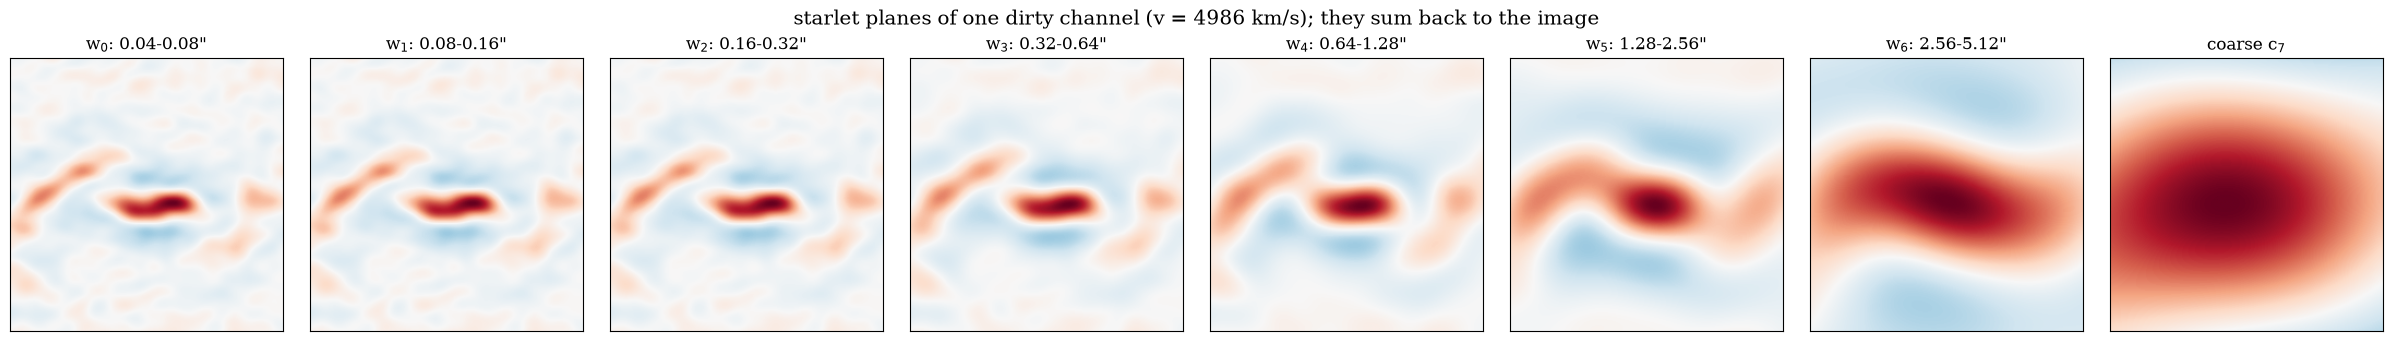

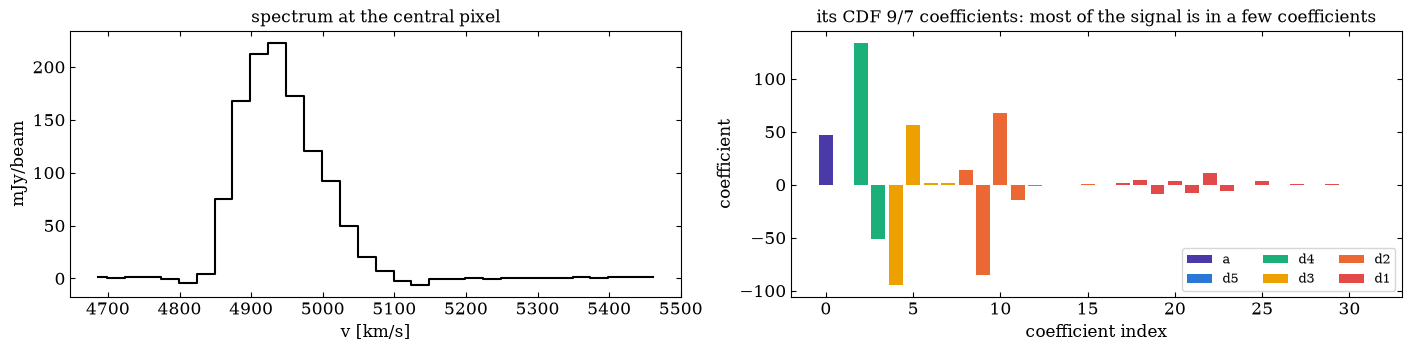

In [11]:
J, L = 7, 5
D = G.Dict2D1D(dirty.shape, J, L)
x_chan = G.to_t(dirty[12:13])                                  # one channel of the dirty cube
planes = G.starlet(x_chan, J)[:, 0].cpu().numpy()
fig, ax = plt.subplots(1, J + 1, figsize=(3.0 * (J + 1), 3.3), constrained_layout=True)
for j, a in enumerate(ax):
    v = np.abs(planes[j][75:325, 75:325]).max()
    a.imshow(planes[j][75:325, 75:325], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v, extent=EXT10)
    a.set_title(f"w$_{j}$: {2**j * 0.04:.2f}-{2**(j+1) * 0.04:.2f}\"" if j < J else "coarse c$_7$"); a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"starlet planes of one dirty channel (v = {vel[12]:.0f} km/s); they sum back to the image"); plt.show()

spec_pix = G.to_t(dirty[:, 200, 200][:, None, None])[None]     # (1, 32, 1, 1)
c = G.cdf_fwd(spec_pix, L)[0, :, 0, 0].cpu().numpy()
fig, ax = plt.subplots(1, 2, figsize=(14, 3.4), constrained_layout=True)
ax[0].step(vel, dirty[:, 200, 200] * 1e3, where="mid", color="k"); ax[0].set_xlabel("v [km/s]"); ax[0].set_ylabel("mJy/beam")
ax[0].set_title("spectrum at the central pixel")
pos = 0; cols = ["#4a3aa7", "#2a78d6", "#1baf7a", "#eda100", "#eb6834", "#e34948"]
for (name, sl), col in zip(G.band_slices(32, L), cols):
    idx = np.arange(sl.start, sl.stop); ax[1].bar(idx, c[sl] * 1e3, color=col, label=name)
ax[1].set_xlabel("coefficient index"); ax[1].set_ylabel("coefficient"); ax[1].legend(frameon=True, ncol=3, loc="lower right", fontsize=9)
ax[1].set_title("its CDF 9/7 coefficients: most of the signal is in a few coefficients"); plt.show()

xt = G.to_t(dirty); w = D.W(xt); u = torch.randn_like(w)
print(f"W x has {w.numel() / xt.numel():.0f} coefficients per voxel; perfect reconstruction error "
      f"{float((D.Winv(w) - xt).abs().max() / xt.abs().max()):.1e}; adjoint test <Wx,u> vs <x,W^T u>: "
      f"{float((w * u).sum()):.4e} vs {float((xt * D.WT(u)).sum()):.4e}")
del w, u, xt

## 6. The noise model and the thresholds $\lambda_b$

How hard each sub-band is penalized depends on how much noise it contains.
Interferometric noise is **not white**: it has been filtered by the array's
Fourier sampling, just like the signal, so it forms blobs about the size of
the beam. We measure it from the **line-free channels**, which contain no CO:

1. subtract, pixel by pixel, their mean over those channels, which removes
   the continuum;
2. measure their 2D power spectrum $P(\mathbf k)$;
3. simulate a noise cube $n$ with exactly that power spectrum;
4. transform it and measure, per sub-band, the robust spread

$$ \sigma_b^{\text{real}} = \frac{\operatorname{MAD}\big((Wn)_b\big)}{0.6745}; $$

5. do the same for white noise with the same pixel $\sigma$, giving
   $\sigma_b^{\text{white}}$, and set

$$ \lambda_b = k\,\max\!\big(\sigma_b^{\text{real}},\ \sigma_b^{\text{white}}\big). $$

The white-noise floor keeps sub-bands that the array does not measure at all
(tiny $\sigma^{\text{real}}$) from getting $\lambda\approx0$. Without it, anything
there would go unpenalized.

pixel noise sigma = 0.278 mJy/beam (line-free channels, continuum removed)
-> real noise is ~100x weaker than white at the finest scales (the array measures nothing there)
   and ~50x stronger at large scales: a white-noise threshold would fit large-scale noise as emission.


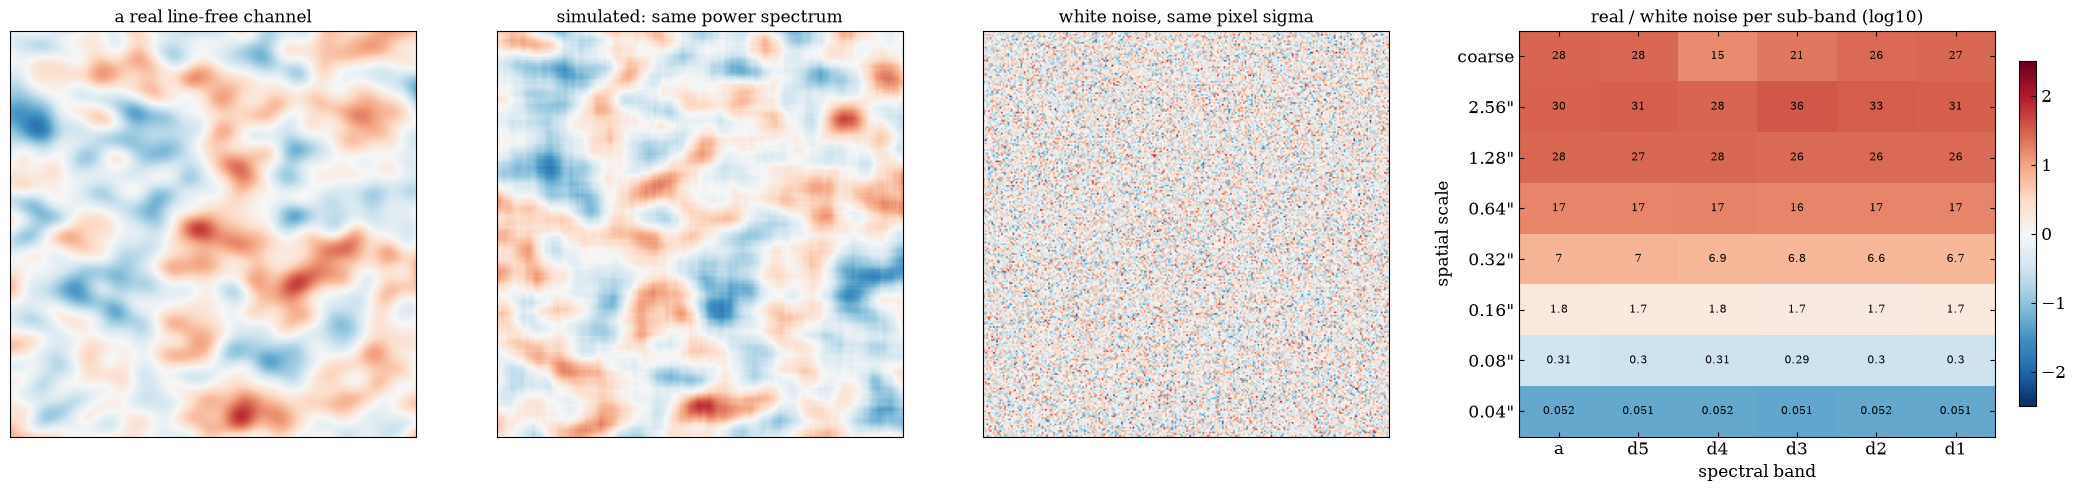

In [13]:
dt = G.to_t(dirty)
npl = G.noise_planes(dt, NOISE)
lam1, sig_real, sig_white, s_pix = G.noise_lambdas(D, dt, NOISE, k=2.0)
ps = G.measured_ps(npl)
sim = G.noise_with_ps(ps, dirty.shape, seed=1)
white = torch.randn(dirty.shape, device=G.DEV) * s_pix
print(f"pixel noise sigma = {s_pix * 1e3:.3f} mJy/beam (line-free channels, continuum removed)")

fig, ax = plt.subplots(1, 4, figsize=(21, 4.8), constrained_layout=True)
for a, img, t in ((ax[0], npl[0], "a real line-free channel"), (ax[1], sim[0], "simulated: same power spectrum"),
                  (ax[2], white[0], "white noise, same pixel sigma")):
    v = 4 * s_pix; a.imshow(img.cpu().numpy()[75:325, 75:325], origin="lower", cmap="RdBu_r", vmin=-v, vmax=v, extent=EXT10)
    a.set_title(t); a.set_xticks([]); a.set_yticks([])
R = np.log10((sig_real / sig_white)[:, [sl.start for _, sl in D.bands], 0, 0].cpu().numpy())
im = ax[3].imshow(R, origin="lower", cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax[3].set_xticks(range(len(D.bands))); ax[3].set_xticklabels([n for n, _ in D.bands]); ax[3].set_yticks(range(J + 1))
ax[3].set_yticklabels([f"{2**j * 0.04:.2f}\"" for j in range(J)] + ["coarse"])
ax[3].set_xlabel("spectral band"); ax[3].set_ylabel("spatial scale"); ax[3].set_title("real / white noise per sub-band (log10)")
for j in range(R.shape[0]):
    for b in range(R.shape[1]):
        ax[3].text(b, j, f"{10**R[j, b]:.2g}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax[3], shrink=0.85); plt.show()
print("-> real noise is ~100x weaker than white at the finest scales (the array measures nothing there)\n"
      "   and ~50x stronger at large scales: a white-noise threshold would fit large-scale noise as emission.")
del sim, white

## 7. The solver: Condat-Vu primal-dual

The deconvolved cube is the solution of

$$ \boxed{\;\hat x \;=\; \arg\min_{x\,\ge\,0}\;\; \tfrac12\,x^{\mathsf T}Nx - d^{\mathsf T}x
\;+\; \sum_b \lambda_b\,\big\|(Wx)_b\big\|_1\;} $$

* the first two terms: **fit the data** (the visibility $\chi^2$, step 4);
* $\sum_b\lambda_b\|(Wx)_b\|_1$: **be sparse in the 2D-1D dictionary**, with
  each sub-band's penalty set by its noise (step 6);
* $x\ge0$: CO emission is positive.

**Why not FISTA?** FISTA needs the *proximal operator* of the penalty: the
image closest to a given one that is also cheap under the penalty. For a
redundant, non-orthogonal dictionary like the starlet, "transform, shrink the
coefficients, transform back" is *not* that operator, so the notebook's
FISTA loop does not minimize anything and settles on a blurred image. The
primal-dual method avoids the problem. It keeps a second variable $u$ in
coefficient space and alternates two simple, exact steps:

$$ x^{+} = \max\!\Big(0,\; x - \tau\big(\underbrace{Nx - d}_{\text{data gradient}} + W^{\mathsf T}u\big)\Big) $$
$$ u^{+} = \operatorname{clip}\!\big(u + \sigma\,W(2x^{+}-x),\; -\lambda_b,\; +\lambda_b\big) $$

The first step is a gradient step on the data, pushed by the current
sparsity "forces" $W^{\mathsf T}u$, then clipped to $x\ge0$. The second
accumulates those forces, each capped at $\pm\lambda_b$; the cap is what
produces sparsity. The step sizes are $\tau=1/\beta$ and
$\sigma=\beta/(2\|W\|^2)$, with $\beta$ from step 4 and $\|W\|^2$ from power
iteration. They satisfy the convergence condition, so the iteration converges
to the exact minimizer.

**The run:** $k=2$, 20,000 iterations, starting from $x=0$. From iteration
6000, every 2000 iterations, the penalties are **reweighted**:

$$ \lambda_b \;\to\; \frac{\lambda_b}{\,|Wx|/\lambda_b + \varepsilon\,}, \qquad \varepsilon = 1 . $$

Coefficients much larger than the noise are then penalized less, which
reduces the L1 bias (the systematic shrinkage of real signal). Its effect here
is small (about 1% on a simulation with known truth), and it does not change
the residual; the bumps it causes in the convergence curve are the solver
readjusting to the new penalties.

In [15]:
t0 = time.time()
x1, u1, hist1, snaps1 = G.solve_pd(op, D, lam1, n_iter=20000, beta=beta,
                                   reweight=dict(start=6000, every=2000, eps=1.0),
                                   snaps=(100, 1000, 4000, 20000), print_every=2000)
print(f"20,000 iterations: {time.time() - t0:.0f} s")
model = G.upsample(x1.cpu().numpy().astype(np.float64), 2)          # back to 0.02", Jy/pixel
os.makedirs(f"{DATA}/compact/pd", exist_ok=True); np.save(f"{DATA}/compact/pd/model.npy", model.astype(np.float32))
print(f"model flux {model.sum():.2f} Jy (sum over voxels); saved {DATA}/compact/pd/model.npy")
gif_run = f"{DATA}/compact/pd/model_20k_iterations.npy"          # same recipe, run by scripts/make_pd_evolution_gif.py
if os.path.exists(gif_run):
    ref = np.load(gif_run).astype(np.float64)
    print(f"agreement with the independent run of scripts/make_pd_evolution_gif.py: relative difference "
          f"{np.linalg.norm(model - ref) / np.linalg.norm(ref):.3f} (GPU float32 non-determinism)")

iter      0  flux   13.103  change 1.00e+00  resid rms 1.962e-02
iter   2000  flux   27.638  change 9.67e-05  resid rms 6.927e-04
iter   4000  flux   27.655  change 2.87e-05  resid rms 6.938e-04
iter   6000  flux   27.659  change 1.81e-05  resid rms 6.937e-04
iter   8000  flux   27.673  change 2.12e-05  resid rms 6.941e-04
iter  10000  flux   27.677  change 1.65e-05  resid rms 6.941e-04
iter  12000  flux   27.679  change 1.54e-05  resid rms 6.941e-04
iter  14000  flux   27.681  change 1.48e-05  resid rms 6.941e-04
iter  16000  flux   27.683  change 1.39e-05  resid rms 6.941e-04
iter  18000  flux   27.685  change 1.29e-05  resid rms 6.942e-04
iter  19999  flux   27.686  change 1.27e-05  resid rms 6.943e-04
20,000 iterations: 493 s
model flux 27.69 Jy (sum over voxels); saved ../data/ngc3110/compact/pd/model.npy
agreement with the independent run of scripts/make_pd_evolution_gif.py: relative difference 0.000 (GPU float32 non-determinism)


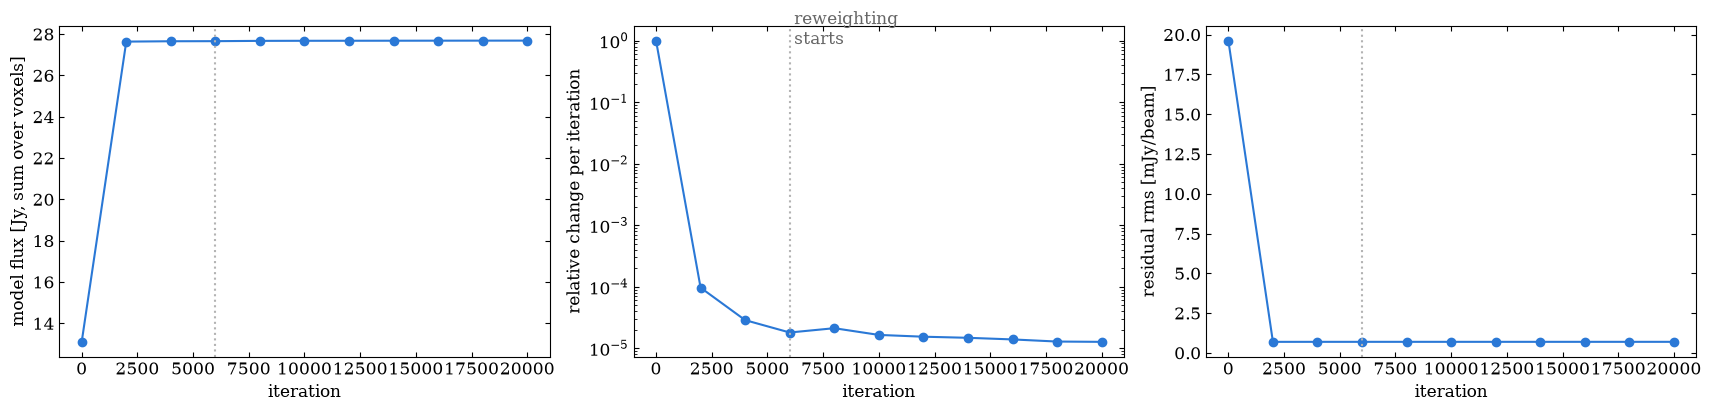

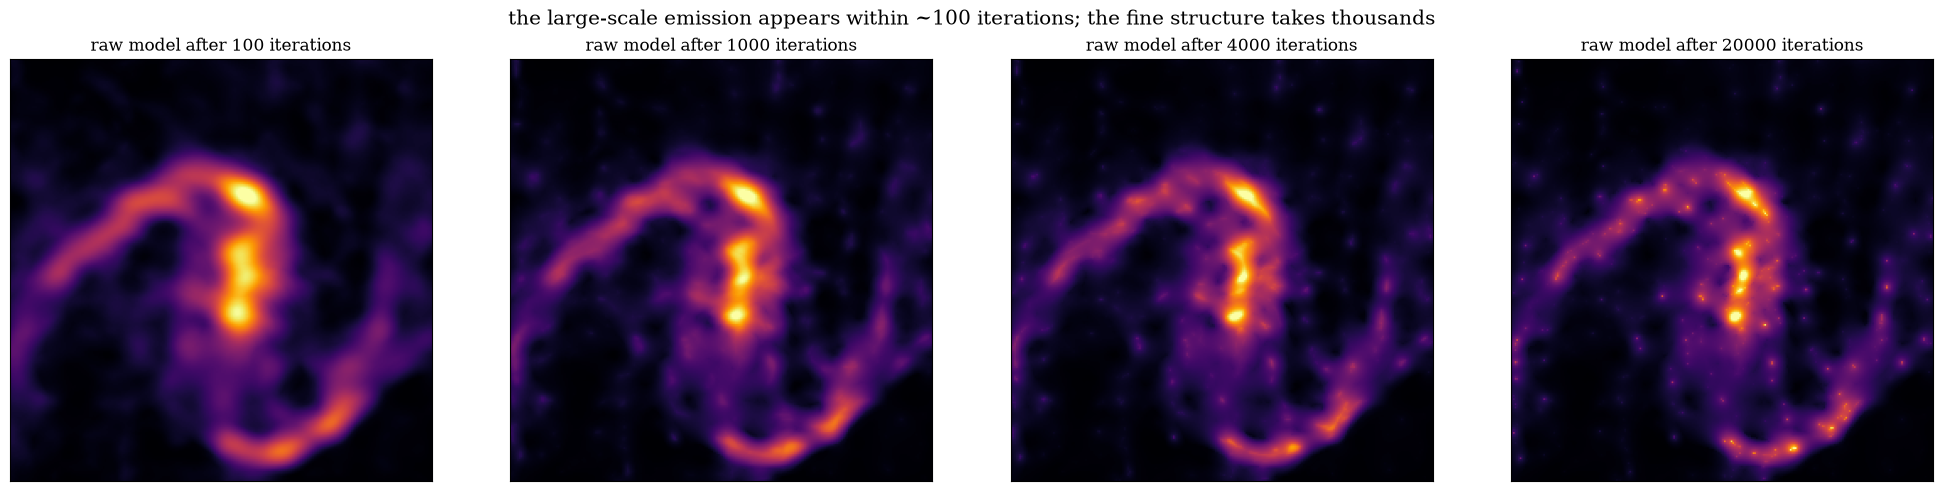

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
it = [h["iter"] for h in hist1]
ax[0].plot(it, [h["flux"] for h in hist1], "o-", color="#2a78d6"); ax[0].set_ylabel("model flux [Jy, sum over voxels]")
ax[1].semilogy(it, [h["rel_change"] for h in hist1], "o-", color="#2a78d6"); ax[1].set_ylabel("relative change per iteration")
ax[2].plot(it, [h["resid_rms"] * 1e3 for h in hist1], "o-", color="#2a78d6"); ax[2].set_ylabel("residual rms [mJy/beam]")
for a in ax: a.set_xlabel("iteration"); a.axvline(6000, color="0.7", ls=":")
ax[1].text(6200, ax[1].get_ylim()[1] * 0.5, "reweighting\nstarts", color="0.4")
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)
for a, (n, xs) in zip(ax, snaps1.items()):
    m = mom0(G.upsample(xs.astype(np.float64), 2))[C10]
    a.imshow(m, origin="lower", extent=EXT10, cmap="inferno", vmin=0, vmax=np.percentile(m, 99.9))
    a.set_title(f"raw model after {n} iterations"); a.set_xticks([]); a.set_yticks([])
fig.suptitle("the large-scale emission appears within ~100 iterations; the fine structure takes thousands"); plt.show()

## 8. Why so many iterations?

Each step moves every spatial frequency $\mathbf k$ of the model by an amount
proportional to $\tau\,\tilde B(\mathbf k) = \tilde B(\mathbf k)/\beta$: the
array's sensitivity at that frequency relative to its strongest one. So a
frequency the array measures with relative weight $\tilde B/\beta$ needs about

$$ n_{\text{iter}}(\mathbf k) \;\sim\; \frac{\beta}{\tilde B(\mathbf k)} $$

iterations to be fitted. The super-resolved detail lives exactly where the
compact array's transfer function has fallen to 0.1-1% of its peak, so it
needs $10^3$-$10^4$ iterations. The GPU makes that affordable: each
iteration here takes a few hundredths of a second.

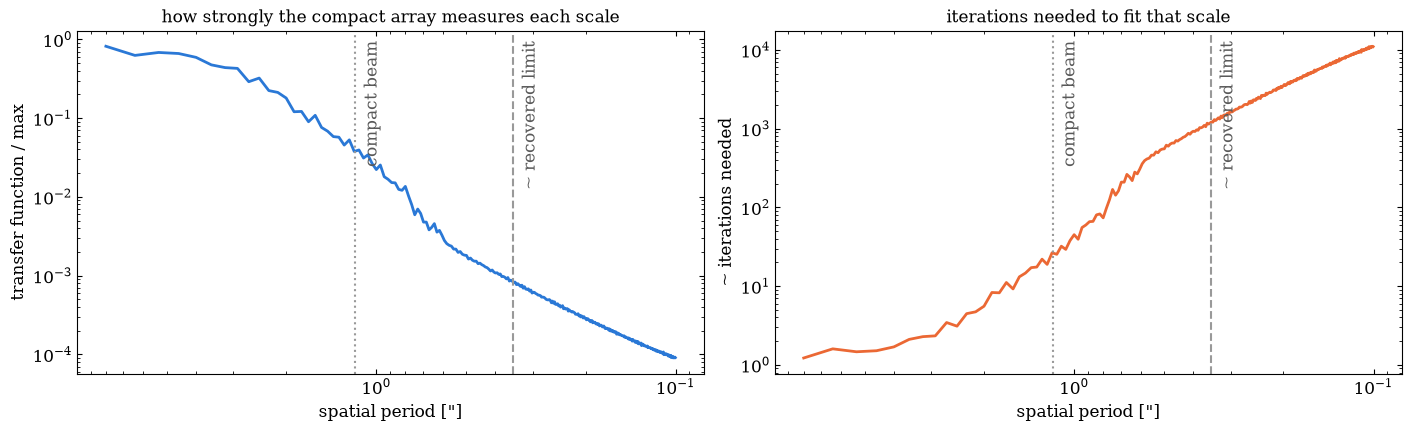

In [18]:
t = np.fft.fftshift(np.abs(np.fft.fft2(np.fft.ifftshift(psf[16]))))
n = t.shape[0]; yy, xx = np.indices(t.shape); rr = np.hypot(yy - n // 2, xx - n // 2).astype(int)
prof = np.bincount(rr.ravel(), t.ravel()) / np.bincount(rr.ravel()); prof /= prof.max()
period = n * 0.04 / np.maximum(np.arange(len(prof)), 1e-9)
sel = (period > 0.1) & (period < 10)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), constrained_layout=True)
ax[0].loglog(period[sel], prof[sel], color="#2a78d6", lw=2); ax[0].invert_xaxis()
ax[0].set_xlabel('spatial period ["]'); ax[0].set_ylabel("transfer function / max"); ax[0].set_title("how strongly the compact array measures each scale")
ax[1].loglog(period[sel], 1 / np.maximum(prof[sel], 1e-6), color="#eb6834", lw=2); ax[1].invert_xaxis()
ax[1].set_xlabel('spatial period ["]'); ax[1].set_ylabel("~ iterations needed"); ax[1].set_title("iterations needed to fit that scale")
for a in ax: a.axvline(1.18, color="0.6", ls=":"); a.axvline(0.35, color="0.6", ls="--")
for a in ax:
    a.text(1.18 / 1.07, 0.97, "compact beam", color="0.35", rotation=90, va="top", ha="left", transform=a.get_xaxis_transform())
    a.text(0.35 / 1.07, 0.97, "~ recovered limit", color="0.35", rotation=90, va="top", ha="left", transform=a.get_xaxis_transform())
plt.show()

## 9. Restoration and units

The model $\hat x$ is in **Jy/pixel**, with no beam at all. To display it at a
chosen resolution, convolve it with a peak-1 elliptical Gaussian $G$, the
**clean beam** CASA fitted to the PSF's main lobe:

$$ I_R = \hat x \ast G \qquad [\text{Jy/beam of } G]. $$

The peak-1 Gaussian conserves flux: $\sum \hat x = \sum I_R \,/\, (\Omega_G/\Omega_{\text{pix}})$.
Jy/beam values are not comparable between beams of different size: the same
emission seen with a beam 36x larger reads about 36x more Jy/beam. So maps
with different beams are shown as **surface brightness**:

$$ S = \frac{I_R}{\Omega_G}, \qquad \Omega_G = \frac{\pi\, b_{\text{maj}}\, b_{\text{min}}}{4\ln 2}
\quad [\text{Jy arcsec}^{-2}]. $$

Unlike CASA's restored image, no residual is added back.

flux check, model (*) compact beam: 26.44 Jy inside the field vs model 27.69 Jy (the rest is spread past the field edge by the beam)
flux check, model (*) extended beam: 26.87 Jy inside the field vs model 27.69 Jy (the rest is spread past the field edge by the beam)


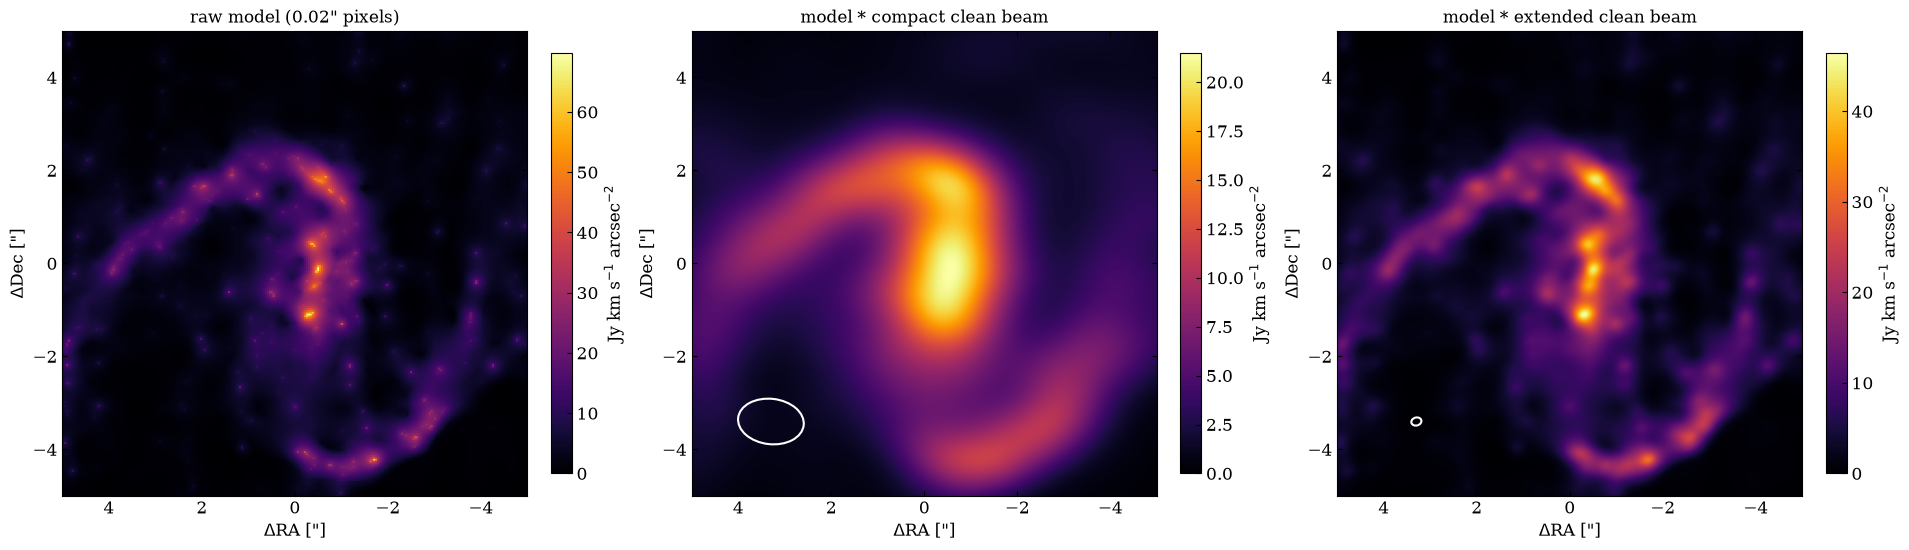

In [20]:
Omega = lambda b: np.pi * b[0] * b[1] / (4 * np.log(2))
rest_c = convolve_with_beam(model, CELL, *BEAM_C); rest_e = convolve_with_beam(model, CELL, *BEAM_E)
for nm, cube, b in (("compact beam", rest_c, BEAM_C), ("extended beam", rest_e, BEAM_E)):
    print(f"flux check, model (*) {nm}: {cube.sum() / (Omega(b) / CELL**2):.2f} Jy inside the field vs model {model.sum():.2f} Jy "
          "(the rest is spread past the field edge by the beam)")
panels = [(mom0(model) / CELL**2, "raw model (0.02\" pixels)", None),
          (mom0(rest_c) / Omega(BEAM_C), "model * compact clean beam", BEAM_C),
          (mom0(rest_e) / Omega(BEAM_E), "model * extended clean beam", BEAM_E)]
fig, ax = plt.subplots(1, 3, figsize=(19, 5.4), constrained_layout=True)
for a, (img, t, b) in zip(ax, panels):
    im = a.imshow(img[C10], origin="lower", extent=EXT10, cmap="inferno", vmin=0, vmax=img[C10].max())
    a.set_title(t); axlabels(a); plt.colorbar(im, ax=a, label=r"Jy km s$^{-1}$ arcsec$^{-2}$", shrink=0.85)
    if b: draw_beam(a, b, x0=3.3, y0=-3.4)
plt.show()

## 10. Validation against the independent extended data

The extended configuration has baselines up to 2.4 km (against 0.45 km for
compact) and a 0.22" x 0.17" beam. It was observed separately and
deconvolved separately (step 11). If the compact deconvolution has truly
recovered structure finer than its own beam, then at the extended beam it
should reproduce the extended map.

Three comparisons, both models at the extended beam:
* the maps and their difference;
* the **coherence** with the extended map, scale by scale:
  $\gamma(k) = \frac{\sum \mathrm{Re}(\tilde A\tilde B^*)}{\sqrt{\sum|\tilde A|^2\sum|\tilde B|^2}}$
  over each ring of spatial frequency. $\gamma = 1$ means identical structure at
  that scale; $\gamma = 0$ means unrelated;
* the integrated spectra.

The reference is the same compact model at its own compact beam, i.e. what a
standard compact image would show.

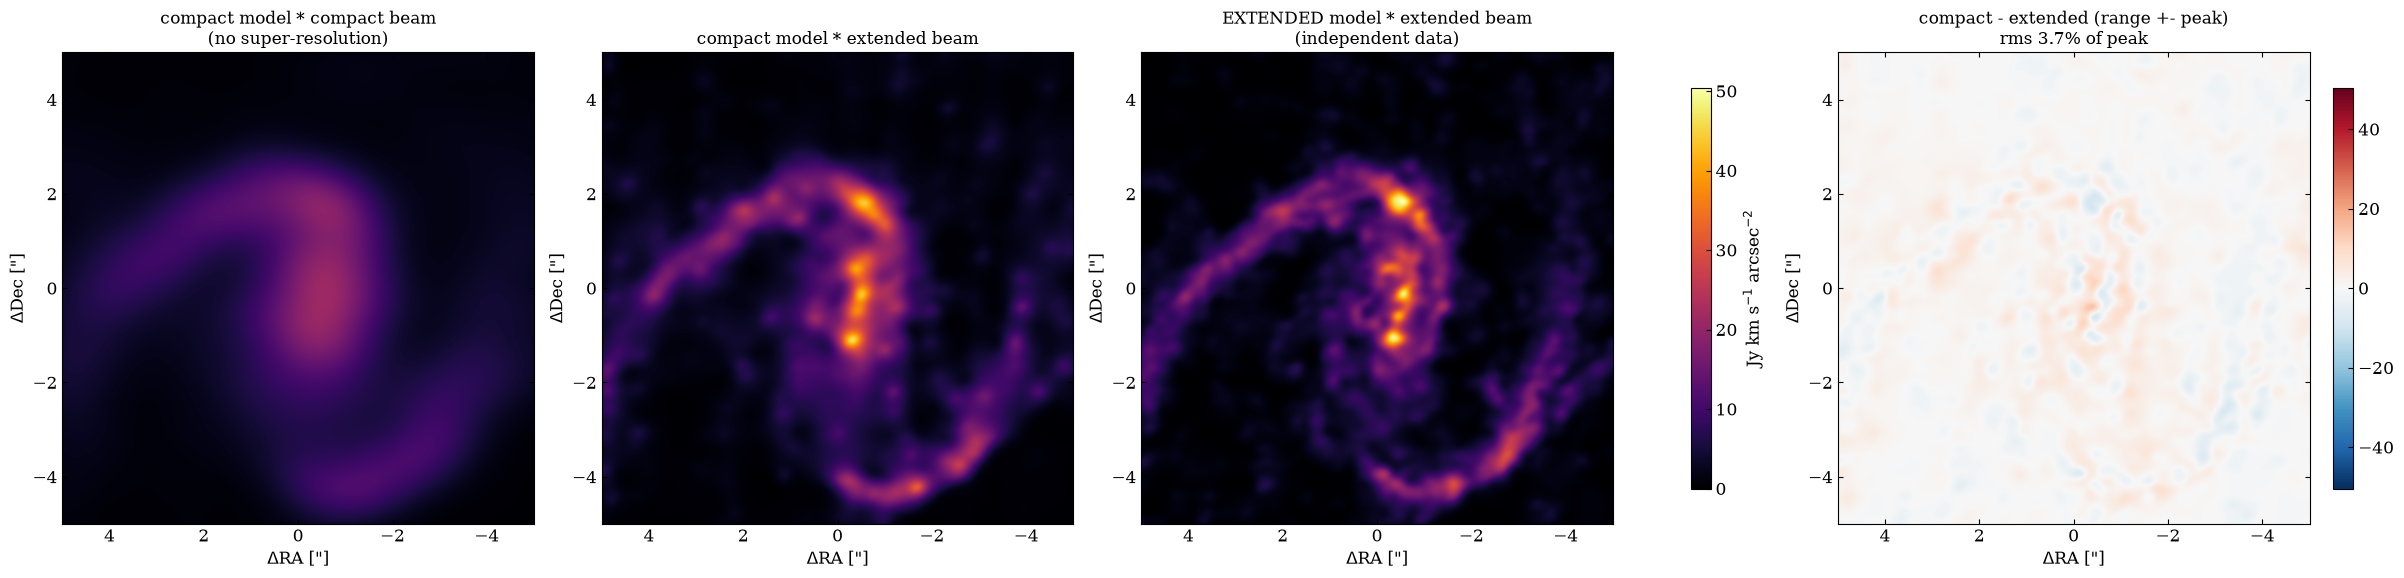

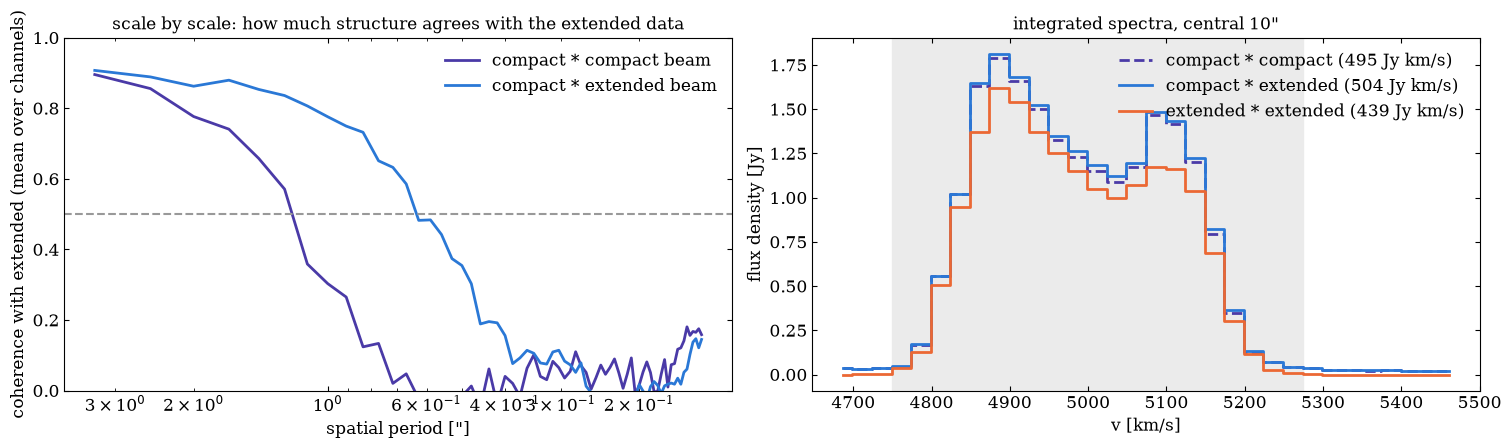

In [22]:
from scipy.signal.windows import tukey
ext_model = np.load(f"{DATA}/extended/pd/model.npy").astype(np.float64)
E = mom0(convolve_with_beam(ext_model, CELL, *BEAM_E)) / Omega(BEAM_E)
Cm = mom0(rest_e) / Omega(BEAM_E); Rm = mom0(rest_c) / Omega(BEAM_C)
vmax = max(Cm[C10].max(), E[C10].max())
fig, ax = plt.subplots(1, 4, figsize=(24, 5.4), constrained_layout=True)
for a, img, t in ((ax[0], Rm, "compact model * compact beam\n(no super-resolution)"), (ax[1], Cm, "compact model * extended beam"),
                  (ax[2], E, "EXTENDED model * extended beam\n(independent data)")):
    im = a.imshow(img[C10], origin="lower", extent=EXT10, cmap="inferno", vmin=0, vmax=vmax); a.set_title(t); axlabels(a)
plt.colorbar(im, ax=ax[:3], label=r"Jy km s$^{-1}$ arcsec$^{-2}$", shrink=0.85)
res = (Cm - E)[C10]
im = ax[3].imshow(res, origin="lower", extent=EXT10, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax[3].set_title(f"compact - extended (range +- peak)\nrms {res.std() / vmax:.1%} of peak"); axlabels(ax[3]); plt.colorbar(im, ax=ax[3], shrink=0.85)
plt.show()

def coherence(a, b):
    n = a.shape[-1]; w = np.outer(tukey(n, 0.25), tukey(n, 0.25))
    A = np.fft.fftshift(np.fft.fft2(a * w)); B = np.fft.fftshift(np.fft.fft2(b * w))
    yy, xx = np.indices((n, n)); r = np.hypot(yy - n // 2, xx - n // 2).astype(int).ravel()
    num = np.bincount(r, (A * np.conj(B)).real.ravel())
    den = np.sqrt(np.bincount(r, (np.abs(A)**2).ravel()) * np.bincount(r, (np.abs(B)**2).ravel()))
    k = np.arange(len(num)) / (n * CELL); m = (k > 0.2) & (k < 7)
    return 1 / k[m], (num / den)[m]
ce = convolve_with_beam(ext_model[LINE], CELL, *BEAM_E)[:, C10[0], C10[1]]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.3), constrained_layout=True)
for cube, col, lab in ((rest_c, "#4a3aa7", "compact * compact beam"), (rest_e, "#2a78d6", "compact * extended beam")):
    per, cs = zip(*[coherence(cube[ch][C10], ce[i]) for i, ch in enumerate(LINE)])
    ax[0].plot(per[0], np.mean(cs, 0), color=col, lw=2, label=lab)
ax[0].axhline(0.5, color="0.6", ls="--"); ax[0].set_xscale("log"); ax[0].invert_xaxis(); ax[0].set_ylim(0, 1)
ax[0].set_xlabel('spatial period ["]'); ax[0].set_ylabel("coherence with extended (mean over channels)"); ax[0].legend(frameon=False)
ax[0].set_title("scale by scale: how much structure agrees with the extended data")
bx = (slice(None), C10[0], C10[1])
for cube, b, col, lab, ls in ((rest_c, BEAM_C, "#4a3aa7", "compact * compact", "--"), (rest_e, BEAM_E, "#2a78d6", "compact * extended", "-"),
                              (convolve_with_beam(ext_model, CELL, *BEAM_E), BEAM_E, "#eb6834", "extended * extended", "-")):
    sp = cube[bx].sum((1, 2)) / (Omega(b) / CELL**2)
    ax[1].step(vel, sp, where="mid", color=col, ls=ls, lw=2, label=f"{lab} ({sp[LINE].sum() * 25:.0f} Jy km/s)")
ax[1].axvspan(vel[LINE[0]] - 12.5, vel[LINE[-1]] + 12.5, color="0.92", zorder=0)
ax[1].set_xlabel("v [km/s]"); ax[1].set_ylabel("flux density [Jy]"); ax[1].legend(frameon=False); ax[1].set_title('integrated spectra, central 10"')
plt.show()

**Reading the plots.** At the extended beam, the compact deconvolution
reproduces the extended map's arms, the three-knot central ridge and the
clumps along the southern arm, with a residual of a few % of the peak. The
coherence shows *where* this holds:
* the compact model at its own beam stops agreeing with the extended data at
  periods of about 1";
* the deconvolved compact model keeps agreeing down to about 0.5";
* agreement fades by about 0.3".

So the prior recovers structure about 3x finer than the compact beam. Below
about 0.3" the compact detail comes from the prior rather than the data. The
spectra agree in shape; the compact data carry slightly more flux, the
diffuse CO the extended array resolves out.

## 11. What is different for the extended cube

The same solver, run on the extended cube alone, leaves a faint **pedestal**
of false flux over the whole field. Two reasons:

* the extended array barely measures scales larger than about 2.5", so noise
  at those scales is barely constrained by the data;
* its noise is about 25x brighter per unit of sky area. The wavelet prior
  removes most of the noise, but, with positivity, what is left accumulates.

The fix is a **support constraint**: $x = 0$ outside a mask $M$. The mask is
grown from the data by repeated detection, each cycle as follows:

1. smooth the current residual over 3 channels and decompose it into starlet
   planes $j = 2\ldots5$ (0.08"-1.3");
2. mark voxels where plane $j$ exceeds both $5\sigma_j$ of matched noise and
   $1.5\times$ (the PSF's sidelobe level at that scale) $\times$ (the plane's
   peak); the second test rejects sidelobes of bright emission;
3. dilate the marks by 10 px and $\pm1$ channel, add them to $M$, and refit
   for 200 iterations with $x = 0$ outside $M$.

This repeats until $M$ stops growing, followed by a 1500-iteration final solve
inside $M$. Otherwise the settings are $k=3$, 8 starlet scales at 0.02", no
reweighting and no pixel term. That run is not repeated here (it uses
`gpu_pd.grow_support`); its result and mask are loaded from
`data/ngc3110/extended/pd/`.

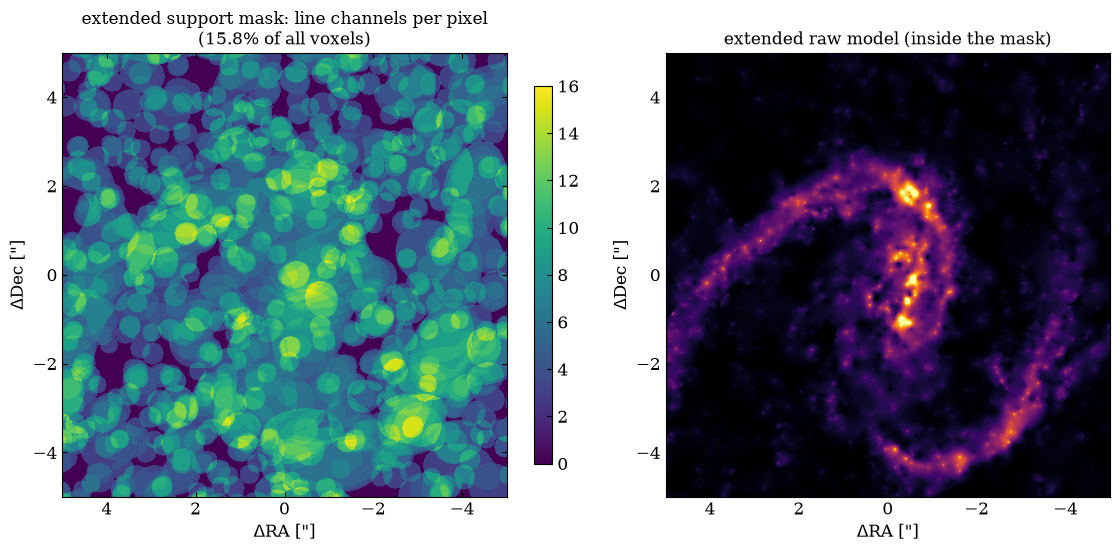

In [25]:
mask = np.load(f"{DATA}/extended/pd/support_mask.npy")
fig, ax = plt.subplots(1, 2, figsize=(12, 5.4), constrained_layout=True)
im = ax[0].imshow(mask[LINE].sum(0)[C10], origin="lower", extent=EXT10, cmap="viridis")
ax[0].set_title(f"extended support mask: line channels per pixel\n({mask.mean():.1%} of all voxels)"); axlabels(ax[0]); plt.colorbar(im, ax=ax[0], shrink=0.85)
m = mom0(ext_model)[C10]
ax[1].imshow(m, origin="lower", extent=EXT10, cmap="inferno", vmin=0, vmax=np.percentile(m, 99.9)); ax[1].set_title("extended raw model (inside the mask)"); axlabels(ax[1])
plt.show()

## Summary of the compact recipe

| step | setting |
|---|---|
| data | compact dirty cube + 2x-field PSF (tclean, natural weighting), 32 x 25 km/s |
| grid | rebinned 2 x 2 to 0.04" (400 x 400), result split back to 0.02" |
| operator | $N x = B\ast x$ by FFT on a 2x padded grid; step $\tau = 1/\beta$ |
| dictionary | 7 starlet scales x 5 CDF 9/7 levels (48 sub-bands) |
| thresholds | $\lambda_b = k\max(\sigma_b^{\text{real}},\sigma_b^{\text{white}})$, noise from line-free channels 0-2, 24-31 |
| solve | $k = 2$, 20,000 iterations from $x = 0$, reweighting ($\varepsilon=1$) every 2000 from 6000 |
| output | `data/ngc3110/compact/pd/model.npy`, Jy/pixel, 0.02", no residual added |

Only the compact data enter. The extended data are used in step 11 alone, as
an independent check.